# 10 - Binarised MNIST: how much information does the model need?

**Section:** FNNs | **Prereqs:** `FNNs/MNIST.ipynb` | **Next:** `FNNs/MinMaxMNIST.ipynb`

Throw away almost all the information in each image - every pixel becomes 0 or 1
by thresholding at the dataset mean - and retrain the same network.

**The result:** accuracy barely drops. Digit identity lives in the *shape* of the
strokes, not in the grey shading, so 1 bit per pixel is nearly enough. This is a
useful instinct: before adding capacity to a model, ask how much of the input
actually carries the signal.

**Also demonstrated:** the other correct loss pairing. This model outputs raw
logits and uses `CrossEntropyLoss`, where `MNIST.ipynb` used
`log_softmax` + `NLLLoss`. Same math, two spellings.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset,DataLoader

from torchvision.transforms import ToTensor
from torchvision.datasets import MNIST

In [3]:
# MNIST: 60000 training and 10000 test images, 28x28 grayscale, digits 0-9.
# torchvision downloads it once into ./data and caches it after that.
data = MNIST(
    root='./data',        # Directory to store the dataset
    train=True,           # Load the training set
    download=True,
    transform = ToTensor()
)

test_data =  MNIST(
    root='./data',        # Directory to store the dataset
    train=False,           # Load the training set
    download=True,
    transform = ToTensor()
)

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.48MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 133kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.72MB/s]


In [4]:
# Flatten to 784 and compute the mean pixel value over the whole training set -
# this becomes the binarisation threshold.
label = data.targets.to('cuda')
data = data.data.view(-1,784).float()
data_mean = torch.mean(data)

In [5]:
# The test set is binarised with data_mean - the TRAINING mean, computed above.
# Using the test set's own mean would be a (mild) leak: a threshold is a learned
# statistic, and every learned statistic must come from the training split.
test_label = test_data.targets.to('cuda')
test_data = test_data.data.view(-1,784).float()
test_data = (test_data > data_mean).float().to('cuda')

In [6]:
# The binarisation: (pixel > mean) -> True/False -> 1.0/0.0.
# 8 bits of grey per pixel collapse to 1 bit.
data = (data > data_mean).float().to('cuda')

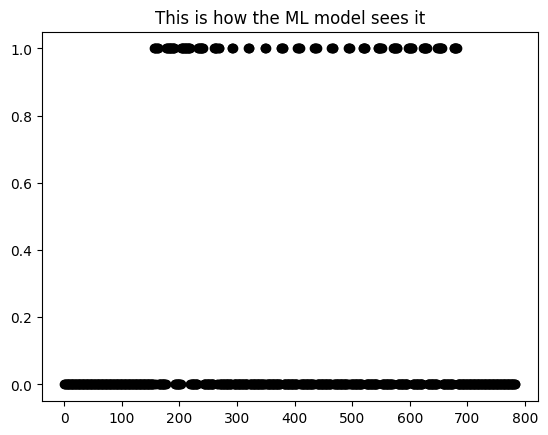

In [7]:
# The 784 input values as the model sees them: a strip of 0s and 1s, with no
# notion that neighbouring entries are neighbouring pixels.
plt.plot(data[0].cpu(), "ko");
plt.title("This is how the ML model sees it");

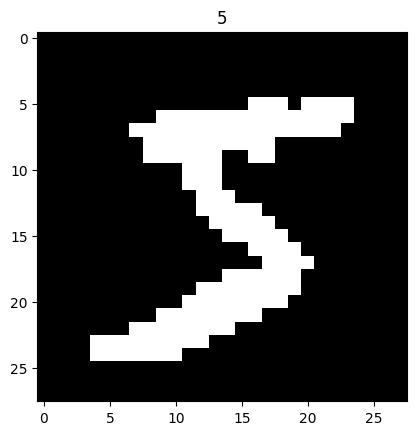

In [8]:
# Reshaped to 28x28 the digit is still perfectly legible to a human. That is
# the whole point of the experiment.
plt.imshow(torch.reshape(data[0].cpu(), (28,28)),cmap='gray')
plt.title(label[0].item());

In [9]:
# Same DataLoader setup as before.
train_data = TensorDataset(data,label)
test_data = TensorDataset(test_data,test_label)

bs = 32
data_loader = DataLoader(train_data, batch_size=bs, drop_last=True, shuffle=True)
test_loader = DataLoader(test_data, batch_size=test_data.tensors[0].shape[0])


In [10]:
# Same architecture as MNIST.ipynb except the final layer returns RAW LOGITS
# (no log_softmax), because the loss below is CrossEntropyLoss.
class model(nn.Module):
  def __init__(self):
    super().__init__()

    self.input_layer = nn.Linear(784, 128)

    self.fc1 = nn.Linear(128,64)

    self.fc2 = nn.Linear(64,32)

    self.output_layer = nn.Linear(32,10)


  def forward(self,x):

    x = F.relu(self.input_layer(x))

    x = F.relu(self.fc1(x))

    x = F.relu(self.fc2(x))

    return self.output_layer(x)

In [11]:
# Identical training function, with CrossEntropyLoss instead of NLLLoss.
# Compare the final accuracy against the full-greyscale run: the gap is small,
# which is the finding.
def train_model():

  classifier = model().to('cuda')

  epochs = 100
  lr = 0.0001

  lossFunc = nn.CrossEntropyLoss()
  optimizer = torch.optim.Adam(classifier.parameters(), lr=lr)

  test_acc = []
  train_acc = []
  losses = torch.zeros(epochs)


  for i in range(epochs):

    classifier.train()
    batch_acc = []
    batch_loss = []

    for x,y in data_loader:

      yhat = classifier(x)

      loss = lossFunc(yhat,y)
      batch_loss.append(loss.item())


      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      batch_acc.append(100 * torch.mean( (torch.argmax(yhat,dim = 1) == y).float()).cpu() )

    train_acc.append(np.mean(batch_acc))
    losses[i] = np.mean(batch_loss)

    if i % 10 == 0 or i == epochs-1:
      print(f"Epoch {i} : Loss = {losses[i].item()}")

    classifier.eval()
    with torch.no_grad():
      X,Y = next(iter(test_loader))
      Preds = torch.argmax(classifier(X), dim = 1)
      test_acc.append( 100 * torch.mean( (Preds == Y).float()) )


  return losses, train_acc, test_acc, classifier


In [12]:
losses, train_acc, test_acc, classifier = train_model()

Epoch 0 : Loss = 0.7527534365653992
Epoch 10 : Loss = 0.10455352067947388
Epoch 20 : Loss = 0.04995850473642349
Epoch 30 : Loss = 0.022849466651678085
Epoch 40 : Loss = 0.00906310509890318
Epoch 50 : Loss = 0.0027105563785880804
Epoch 60 : Loss = 0.0010042072972282767
Epoch 70 : Loss = 0.002147108782082796
Epoch 80 : Loss = 0.0001527816493762657
Epoch 90 : Loss = 0.001691798446699977
Epoch 99 : Loss = 0.0017703004414215684


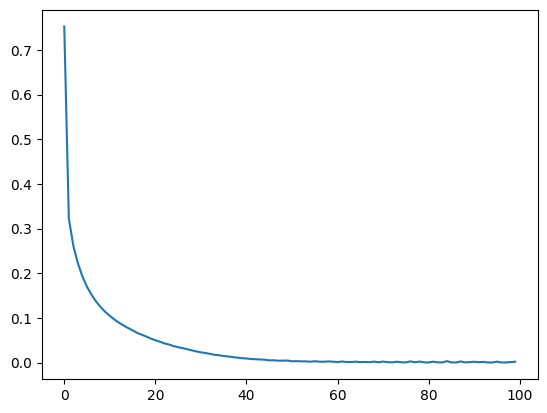

In [13]:
# Loss curve.
plt.plot(losses);

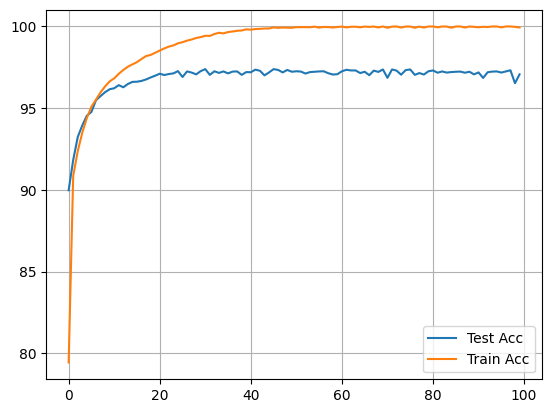

In [14]:
# Train vs test accuracy. Note the gap opens up just like the greyscale run -
# binarising loses information but does not prevent overfitting.
test_acc = [i.cpu() for i in test_acc]

plt.plot(test_acc,label="Test Acc")
plt.plot(train_acc, label="Train Acc")
plt.grid()
plt.legend();

In [15]:
# Final numbers, for comparison with MNIST.ipynb.
test_acc[-1], train_acc[-1]

(tensor(97.0700), np.float32(99.94))

In [18]:
# Because the model emits logits, softmax is applied by hand here to read them
# as probabilities. dim=0 because this is a single sample, not a batch.
a = torch.softmax(classifier(test_data[0][0]).cpu(), dim=0)

In [19]:
a

tensor([2.5664e-19, 7.4357e-18, 7.3375e-19, 1.2985e-18, 7.7769e-26, 1.1662e-21,
        1.0959e-36, 1.0000e+00, 1.0929e-21, 5.2463e-17],
       grad_fn=<SoftmaxBackward0>)

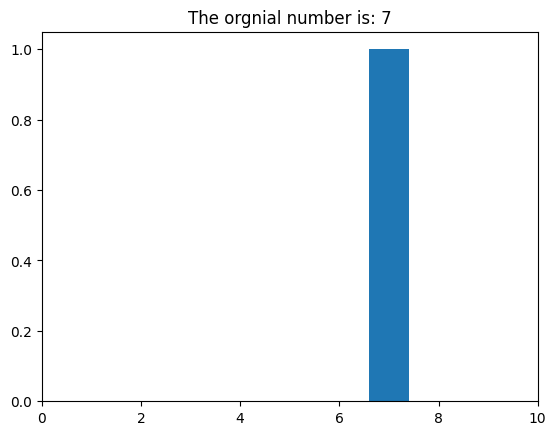

In [40]:
# Probabilities: they sum to 1 and are directly interpretable as confidence.
plt.bar(range(10),a.detach())
plt.xlim([0,10])
plt.title(f"The orgnial number is: {test_label[0].item()}");

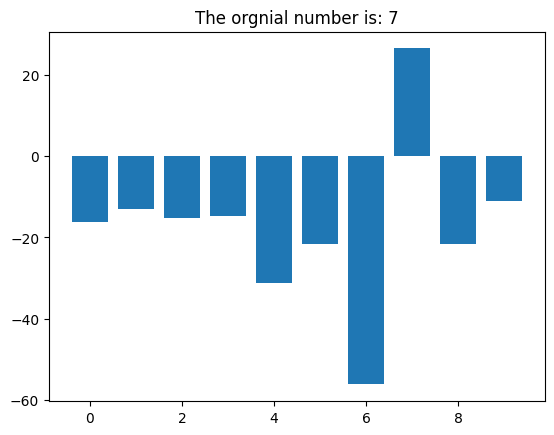

In [47]:
# The same prediction as raw logits: unbounded, can be negative, and only the
# ORDER is meaningful. argmax gives the same answer either way, which is why no
# softmax is needed to make a prediction - only to interpret one.
plt.bar(range(10),classifier(test_data[0][0]).detach().cpu());
plt.title(f"The orgnial number is: {torch.argmax(classifier(test_data[0][0]))}");

torch.Size([10])